In [56]:
# ===== IMPORTS =====
import yaml
import dask

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.ndimage import label, sum_labels
from mpl_toolkits.axes_grid1 import make_axes_locatable

from resoterre.config_utils import config_from_yaml
from resoterre.experiments.crcm_emulator.crcm_emulator_workflow import CRCMEmulatorConfig

from resoterre import PROJECT_ROOT
from resoterre.hybrid_data_loaders.crcm_emulator_data_loader import CRCMEmulatorDataset

In [57]:
# ===== CONFIG =====
config_path = PROJECT_ROOT / "configs" / "crcm_emulator" / "crcm_emulator.yaml"
config = config_from_yaml(CRCMEmulatorConfig, config_path)

path_data = Path(config.path_data)
path_preprocessed = path_data / config.path_preprocessed

assert path_preprocessed.exists(), path_preprocessed

In [58]:
# ===== INIT DATASET =====
data_params = {
    "path_gcm_preprocessing": path_preprocessed,
    "path_crcm_preprocessing": path_preprocessed,
    "simulations": [config.preprocessing_simulations[0], config.preprocessing_simulations[1]],
    "gcm_variables": config.gcm_training_variables,
    "crcm_variables": config.crcm_training_variables,
    "time_periods": config.training_periods,
    "apply_normalization": False
}
dataset = CRCMEmulatorDataset(**data_params)

In [59]:
sample = dataset[0]
print(sample.keys())
print(f"gcm_variables: {dataset.gcm_variables}")
print(f"crcm_variables: {dataset.crcm_variables}")

dict_keys(['input_first_block', 'target', 'year', 'month', 'day', 'CO2', 'CH4', 'N2O', 'CFC12', 'CFC11_eq'])
gcm_variables: ['ta1000', 'ta850']
crcm_variables: ['tas']


In [60]:
with open("valid_idx_output.txt", "w") as f:
    for idx in dataset.valid_idx:
        f.write(f"{idx}\n")

In [61]:
# ===== COMPUTE STATS =====
def select_valid_times(obj, indices):
    """Return only the requested valid time steps (where both GCM and RCM data are present) from an xarray object.

    If requested indices are contiguous, use a slice for efficiency. 
    Otherwise, select each index individually.

    Args:
        obj (xarray.DataArray or xarray.Dataset): 
            The data object to select time steps from.
        indices (array-like of int): 
            Indices along the 'time' dimension representing valid time steps with joint GCM-RCM coverage.

    Returns:
        xarray.DataArray or xarray.Dataset: 
            The subset of `obj` for the requested valid time steps only.
    """
   
    indices = np.unique(np.asarray(indices, dtype=np.int64))

    if len(indices) > 0 and (indices[-1] - indices[0] + 1 == len(indices)):
        # Contiguous: use a slice for efficiency
        return obj.isel(time=slice(int(indices[0]), int(indices[-1]) + 1))
    else:
        # Non-contiguous: select each index individually
        return obj.isel(time=indices)

def compute_stats(ds):
    """
    Calculates statistics over a dataset using a single Dask computation graph for efficiency.

    Computes scalars (count, sum, sum of squares, min, max, percent NaN),
    as well as temporal and spatial means, applying skipna so NaN values do not affect the results.
    Use one Dask graph to calculate all statistics in a single pass.

    Args:
        ds (xarray.DataArray or xarray.Dataset): 
            The data object for which to compute statistics (dims: time, rlat, rlong)

    Returns:
        dict: 
            Dictionary of statistics including:
            - 'count', 'sum', 'sumsq', 'min', 'max', 'pct_nan', 
              'temporal_mean', 'spatial_mean'.
    """
    spatial_dims = [d for d in ds.dims if d != "time"] # rlat and rlong (spatial dims)
    count = ds.notnull().sum()
    total = ds.sum(skipna=True)
    sumsq = (ds ** 2).sum(skipna=True)
    return {
        "count": count, # intermediate stat for mean & stdev
        "sum": total, # intermediate stat for mean & stdev
        "sumsq": sumsq, # intermediate stat for stdev
        "min": ds.min(skipna=True),
        "max": ds.max(skipna=True),
        "percent_missing": ds.isnull().mean() * 100,
        "temporal_mean": ds.mean("time", skipna=True),
        "spatial_mean": ds.mean(spatial_dims, skipna=True),
    }

def summarize_to_dataframe(sim_name, model_type, stats):
    """
    Summarizes statistics from a dataset into a pandas DataFrame.
    Converts intermediate statistics into final summary metrics.
    """
    rows = []
    for var in stats["count"].data_vars: 
        print(f"Summarizing {var} for {sim_name} from {model_type}")
        count = float(stats["count"][var])
        sum = float(stats["sum"][var])
        sum_of_squares = float(stats["sumsq"][var])
   
        mean = sum / count if count else np.nan
        variance = (sum_of_squares / count - mean**2) if count else np.nan  # population variance, matches xarray .std(ddof=0)
        std = np.sqrt(variance) if variance >= 0 else np.nan
        vmin = float(stats["min"][var])
        vmax = float(stats["max"][var])

        n_samples = int(stats["spatial_mean"].sizes["time"])

        rows.append({
            "sim": sim_name,
            "model": model_type,
            "variable": var,
            "n_samples": n_samples,
            "total non_nan values": int(count), # n_samples × n_lat × n_lon - NaNs
            "mean": mean,
            "std": std,
            "min": vmin,
            "max": vmax,
            "range": vmax - vmin,
            "pct_nan": float(stats["percent_missing"][var]),    
        })
    return pd.DataFrame(rows)

In [62]:
# ==== SUMMARIZE DATA =====

start_date = np.datetime64("1991-01-01")
end_date   = np.datetime64("2020-12-31")

# Organize valid GCM and CRCM indices for each simulation into a dictionary keyed by simulation name
indicies_by_sim = {}

for gcm_str, gcm_idx, crcm_idx in dataset.valid_idx:
    indicies_by_sim.setdefault(gcm_str, {"gcm": [], "crcm": []})
    indicies_by_sim[gcm_str]["gcm"].append(gcm_idx)
    indicies_by_sim[gcm_str]["crcm"].append(crcm_idx)

frames = []
maps = {}
data_gcm = {}
data_crcm = {}

# Compute stats for each simulation
# filter dataset here
for sim, idxs in list(indicies_by_sim.items()):
    gcm_ds = dataset.get_open_dataset("gcm", sim)
    times = gcm_ds["time"]
    in_range = ((times >= start_date) & (times <= end_date)).values
    keep = [i for i, t_idx in enumerate(idxs["gcm"]) if in_range[t_idx]]
    idxs["gcm"]  = [idxs["gcm"][i] for i in keep]
    idxs["crcm"] = [idxs["crcm"][i] for i in keep]

    if not idxs["gcm"]:
        print(f"skip {sim}: no days in {start_date} → {end_date}")
        del indicies_by_sim[sim]
        continue

    print(sim, start_date, "→", end_date, "n_days =", len(idxs["gcm"]))
    data_gcm[sim] = select_valid_times(gcm_ds[dataset.gcm_variables], idxs["gcm"])
    data_crcm[sim] = select_valid_times(
        dataset.get_open_dataset("crcm", sim)[dataset.crcm_variables],
        idxs["crcm"],
    )

    gcm_stats, crcm_stats = dask.compute(compute_stats(data_gcm[sim]), compute_stats(data_crcm[sim]))
    frames.append(summarize_to_dataframe(sim, "gcm", gcm_stats))
    frames.append(summarize_to_dataframe(sim, "crcm", crcm_stats))
    maps[(sim, "gcm")] = {"temporal_mean": gcm_stats["temporal_mean"], "spatial_mean": gcm_stats["spatial_mean"]}
    maps[(sim, "crcm")] = {"temporal_mean": crcm_stats["temporal_mean"], "spatial_mean": crcm_stats["spatial_mean"]}

stats_df = pd.concat(frames, ignore_index=True)

CNRM-ESM2-1_historical_r1i1p1f2 1991-01-01 → 2020-12-31 n_days = 8766
Summarizing ta1000 for CNRM-ESM2-1_historical_r1i1p1f2 from gcm
Summarizing ta850 for CNRM-ESM2-1_historical_r1i1p1f2 from gcm
Summarizing tas for CNRM-ESM2-1_historical_r1i1p1f2 from crcm
CNRM-ESM2-1_ssp245_r1i1p1f2 1991-01-01 → 2020-12-31 n_days = 2192
Summarizing ta1000 for CNRM-ESM2-1_ssp245_r1i1p1f2 from gcm
Summarizing ta850 for CNRM-ESM2-1_ssp245_r1i1p1f2 from gcm
Summarizing tas for CNRM-ESM2-1_ssp245_r1i1p1f2 from crcm


In [63]:
pd.set_option('display.float_format', '{:.2f}'.format)
stats_df

,sim,model,variable,n_samples,total non_nan values,mean,std,min,max,range,pct_nan
0,CNRM-ESM2-1_historical_r1i1p1f2,gcm,ta1000,8766,26393592,285.05,13.86,223.22,310.40,87.18,47.87
1,CNRM-ESM2-1_historical_r1i1p1f2,gcm,ta850,8766,45386741,276.43,12.02,227.67,306.69,79.02,10.36
2,CNRM-ESM2-1_historical_r1i1p1f2,crcm,tas,8766,3240474624,281.29,16.59,199.84,312.88,113.03,0.00
3,CNRM-ESM2-1_ssp245_r1i1p1f2,gcm,ta1000,2192,6553294,285.67,13.49,225.67,309.26,83.58,48.24
4,CNRM-ESM2-1_ssp245_r1i1p1f2,gcm,ta850,2192,11345913,276.93,11.92,230.05,307.23,77.18,10.39
5,CNRM-ESM2-1_ssp245_r1i1p1f2,crcm,tas,2192,810303488,281.86,16.34,203.31,312.56,109.25,0.00


In [64]:
def nan_cluster_sizes(mask_2d, connectivity=8):
    """Connected-component sizes (pixels) in a 2D NaN mask, largest first."""
    neighbourhood = np.ones((3, 3)) if connectivity == 8 else np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
    labeled, n_clusters = label(mask_2d, structure=neighbourhood)
    if n_clusters == 0:
        return np.array([])
    sizes = sum_labels(mask_2d, labeled, index=np.arange(1, n_clusters + 1))
    return np.sort(sizes)[::-1]


def max_largest_cluster_pct(mask_3d):
    """Max over time of the largest NaN cluster, as a percent of the image.

    Parameters
    ----------
    mask_3d : np.ndarray
        Boolean array of shape (time, y, x); True where NaN.
    """
    n_pixels = mask_3d.shape[1] * mask_3d.shape[2]
    max_pct = 0.0
    for t in range(mask_3d.shape[0]):
        sizes = nan_cluster_sizes(mask_3d[t])
        if len(sizes):
            max_pct = max(max_pct, 100.0 * float(sizes[0]) / n_pixels)
    return max_pct

rows = []
for sim, ds in data_gcm.items():
    for var in dataset.gcm_variables:
        nan_mask = ds[var].isnull()
        nan_arr = nan_mask.compute().values  # (time, y, x)
        n_pixels = nan_arr.shape[1] * nan_arr.shape[2]
        mostly = nan_arr.mean(axis=0) > 0.95
        ever = nan_arr.any(axis=0)
        pct_transient_nan = 100.0 * (ever.sum() - mostly.sum()) / n_pixels
        sizes = nan_cluster_sizes(mostly)
        cluster_pcts = 100.0 * sizes / n_pixels if len(sizes) else np.array([])

        rows.append({
            "sim": sim,
            "variable": var,
            "pct_mostly_nan": 100.0 * mostly.sum() / n_pixels,
            "pct_transient_nan": pct_transient_nan,
            "n_clusters": int(len(sizes)),
            "max_cluster_pct": float(cluster_pcts[0]) if len(cluster_pcts) else np.nan,
            "min_cluster_pct": float(cluster_pcts[-1]) if len(cluster_pcts) else np.nan,
            "max_cluster_pct_over_time": max_largest_cluster_pct(nan_arr),
            "cluster_pcts": np.round(cluster_pcts, 2),
        })
        print(var, sim, f"{nan_arr.shape[0]} timesteps")
pd.DataFrame(rows)

ta1000 CNRM-ESM2-1_historical_r1i1p1f2 8766 timesteps
ta850 CNRM-ESM2-1_historical_r1i1p1f2 8766 timesteps
ta1000 CNRM-ESM2-1_ssp245_r1i1p1f2 2192 timesteps
ta850 CNRM-ESM2-1_ssp245_r1i1p1f2 2192 timesteps


,sim,variable,pct_mostly_nan,pct_transient_nan,n_clusters,max_cluster_pct,min_cluster_pct,max_cluster_pct_over_time,cluster_pcts
0,CNRM-ESM2-1_historical_r1i1p1f2,ta1000,41.60,43.25,6,39.63,0.16,63.69,"[39.63, 0.87, 0.36, 0.35, 0.24, 0.16]"
1,CNRM-ESM2-1_historical_r1i1p1f2,ta850,9.33,3.90,4,5.57,0.24,9.87,"[5.57, 2.87, 0.64, 0.24]"
2,CNRM-ESM2-1_ssp245_r1i1p1f2,ta1000,42.21,39.21,6,40.24,0.16,65.44,"[40.24, 0.87, 0.36, 0.35, 0.24, 0.16]"
3,CNRM-ESM2-1_ssp245_r1i1p1f2,ta850,9.18,3.90,4,5.42,0.24,9.64,"[5.42, 2.87, 0.64, 0.24]"


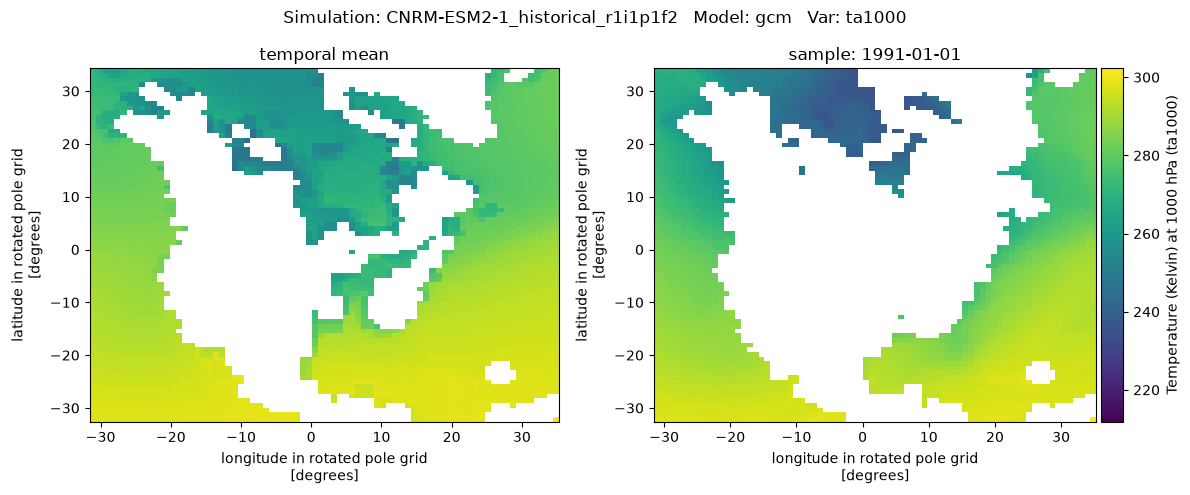

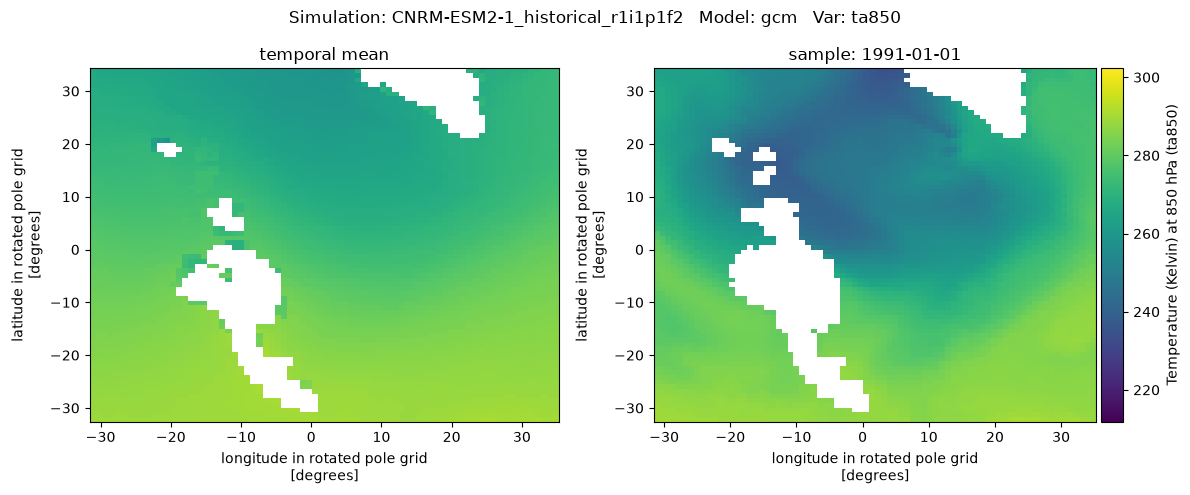

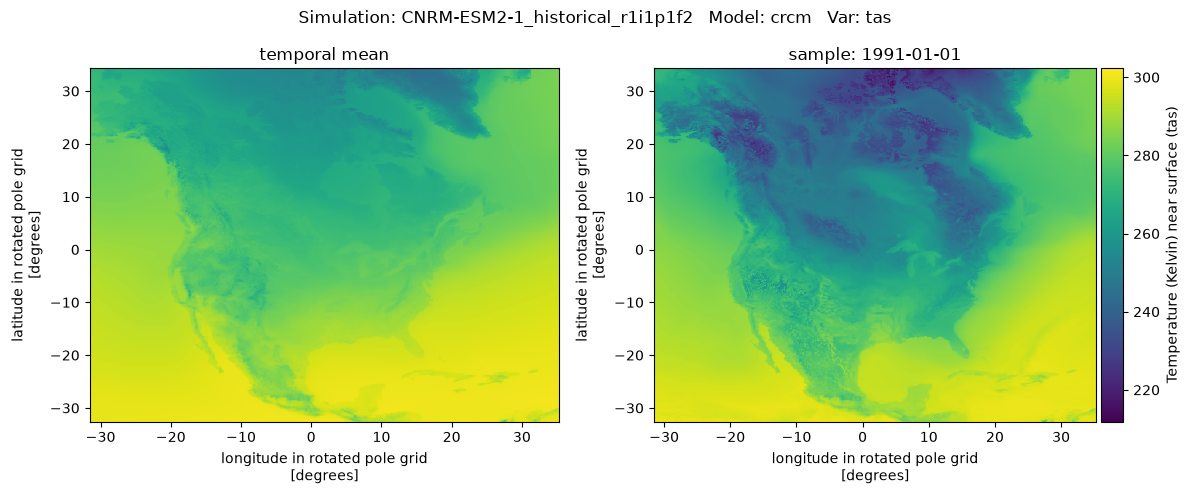

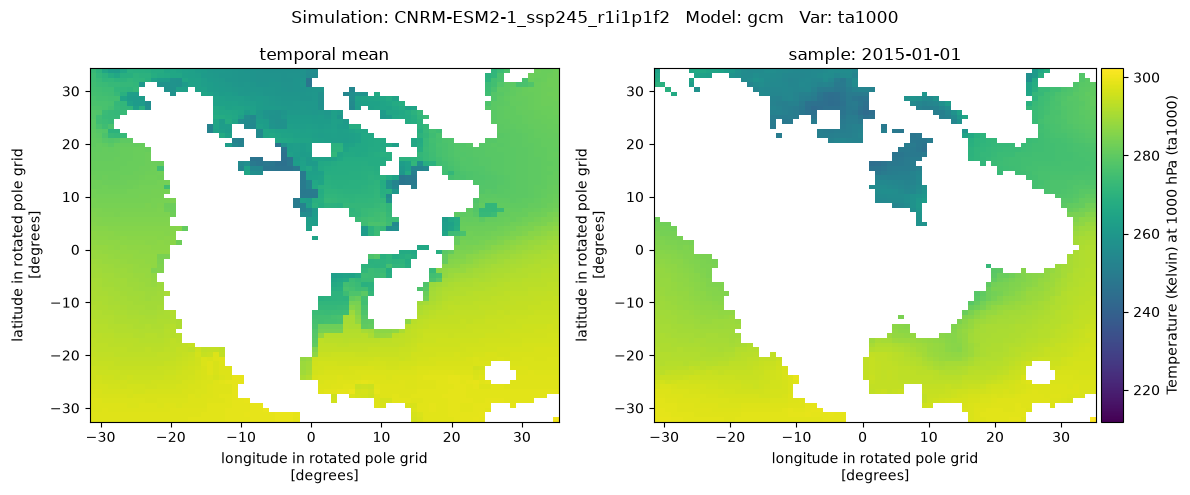

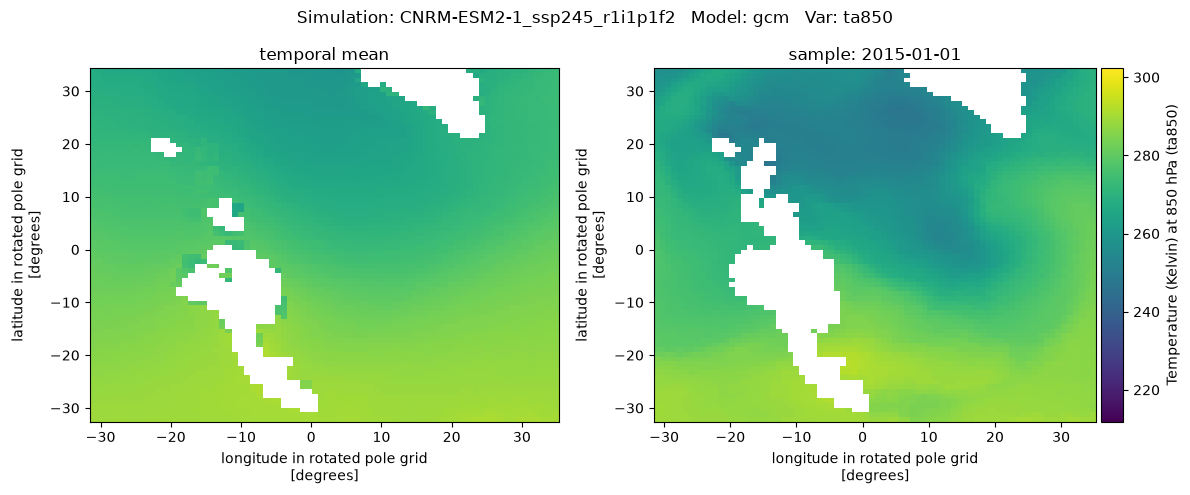

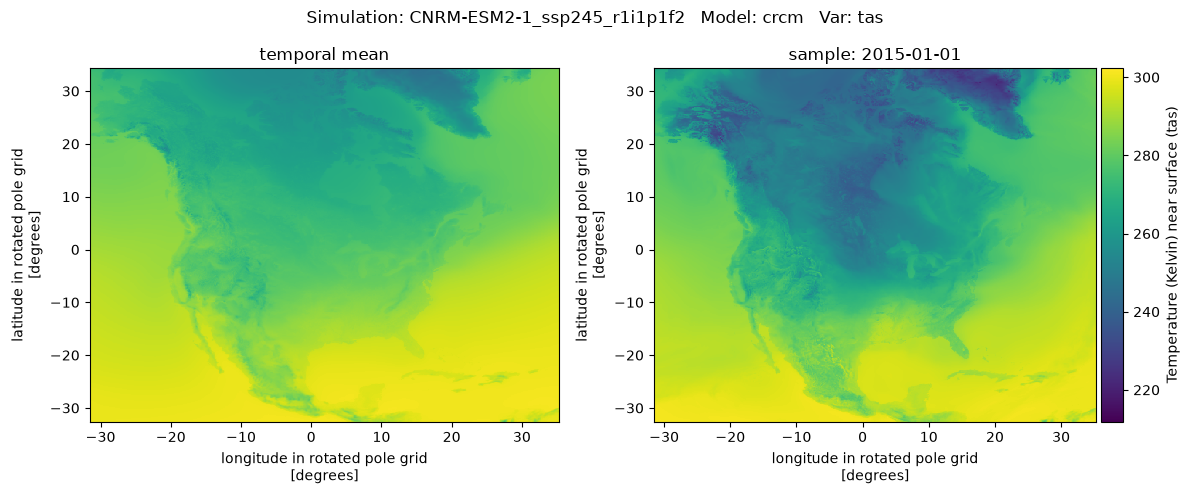

In [86]:
# ==== PLOT DATA =====
def first_sample(sim, model, var):
    ds = data_gcm[sim] if model == "gcm" else data_crcm[sim]
    sample = ds[var].isel(time=0)
    sample_time = ds["time"].isel(time=0).values
    # Pull date only as string (YYYY-MM-DD), regardless of cftime or np.datetime64
    if hasattr(sample_time, 'strftime'):
        date_label = sample_time.strftime('%Y-%m-%d')
    else:
        # Fallback for np.datetime64 or string
        date_label = str(sample_time)[:10]
    return sample, date_label

def variable_pretty_label(var):
    # Map variable codes to preferred names/levels, extend as necessary.
    pretty_names = {
        "ta1000": ("Temperature (Kelvin) at 1000 hPa", "ta1000"),
        "ta850": ("Temperature (Kelvin) at 850 hPa", "ta850"),
        "tas": ("Temperature (Kelvin) near surface", "tas"),
        # Add maps as appropriate for other variables...
    }
    return pretty_names.get(var, (f"{var}", var))

# ---- Compute global vmin/vmax for each variable across all scenarios/models ----
global_vmin_vmax = {}

# Find absolute global vmin/vmax across all relevant variables (for unified colorbar)
all_gcm_vars = set(dataset.gcm_variables)
all_crcm_vars = set(dataset.crcm_variables)
all_vars = all_gcm_vars.union(all_crcm_vars)

absolute_vmin = {}
absolute_vmax = {}

for var in all_vars:
    this_min = []
    this_max = []
    for (sim, model), stored in maps.items():
        variables = dataset.gcm_variables if model == "gcm" else dataset.crcm_variables
        if var in variables:
            tmean = stored["temporal_mean"][var]
            this_min.append(float(np.nanmin(tmean.values)))
            this_max.append(float(np.nanmax(tmean.values)))
            ds = data_gcm[sim] if model == "gcm" else data_crcm[sim]
            sample = ds[var].isel(time=0)
            this_min.append(float(np.nanmin(sample.values)))
            this_max.append(float(np.nanmax(sample.values)))
    if this_min and this_max:
        global_vmin_vmax[var] = (min(this_min), max(this_max))
        absolute_vmin[var] = min(this_min)
        absolute_vmax[var] = max(this_max)

# Determine the global absolute min and max across all variables (for all value bars to match)
# Only consider variables that will be plotted (i.e., in maps, and actually present as var)
if absolute_vmin and absolute_vmax:
    global_abs_vmin = min(absolute_vmin.values())
    global_abs_vmax = max(absolute_vmax.values())
else:
    global_abs_vmin, global_abs_vmax = None, None

# ---- Plot using the same min/max for all variables for the colorbar ----
for (sim, model), stored in maps.items():
    variables = dataset.gcm_variables if model == "gcm" else dataset.crcm_variables
    for var in variables:
        tmean = stored["temporal_mean"][var]
        sample, date_label = first_sample(sim, model, var)
        # Use the absolute min/max for all plots so that colorbars always match
        vmin = global_abs_vmin
        vmax = global_abs_vmax
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot both images with unified color scale across ALL variables/scenarios
        tmean_image = tmean.plot(ax=axes[0], vmin=vmin, vmax=vmax, add_colorbar=False)
        axes[0].set_title("temporal mean")

        sample.plot(ax=axes[1], vmin=vmin, vmax=vmax, add_colorbar=False)
        axes[1].set_title(f"sample: {date_label}")

        # Add a single, shared colorbar to the right of both plots
        divider = make_axes_locatable(axes[1])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(tmean_image, cax=cax)
        cbar_label, var_code = variable_pretty_label(var)
        cbar.set_label(f"{cbar_label} ({var_code})")

        sim_title = f"Simulation: {sim}   Model: {model}   Var: {var}"
        fig.suptitle(sim_title)
        fig.tight_layout()
        plt.show()

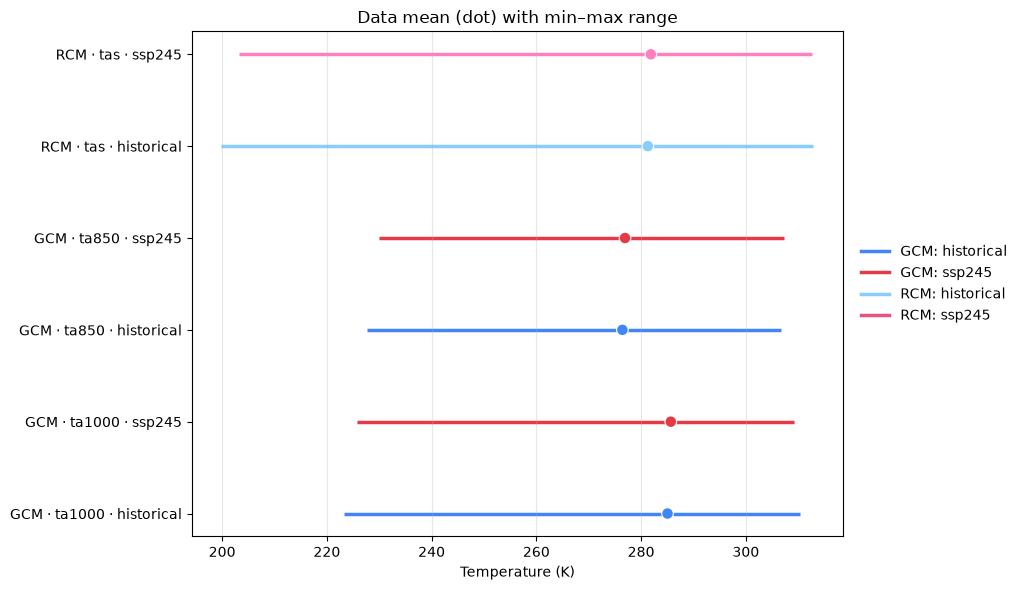

In [83]:
# Six scalar rows: plot the min–max range and mean for each scenario/model/var combo

plot_df = stats_df.copy()
plot_df["sim_short"] = (
    plot_df["sim"]
    .str.replace("CNRM-ESM2-1_", "", regex=False)
    .str.replace("_r1i1p1f2", "", regex=False)
)

plot_df = (
    plot_df[["sim_short", "model", "variable", "n_samples", "mean", "std", "min", "max", "range", "pct_nan"]]
    .sort_values(["variable", "sim_short"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(13, 6))
y = np.arange(len(plot_df))

# colour mapping
def row_color(row):
    # historical: blue, ssp245: red
    if row["variable"] == "tas":
        # crcm tas: baby blue (hist) / pink (ssp245)
        return "#87cefa" if row["sim_short"] == "historical" else "#FF80BF"
    else:
        # gcm: blue (hist) / red (ssp245)
        return "#4285f4" if row["sim_short"] == "historical" else "#e63946"

colors = plot_df.apply(row_color, axis=1)

# Create y-tick labels with RCM/GCM prefix
def model_prefix(row):
    return "RCM" if row["model"].lower() == "crcm" else "GCM"

y_labels = plot_df.apply(lambda row: f'{model_prefix(row)} · {row["variable"]} · {row["sim_short"]}', axis=1)

ax.hlines(y, plot_df["min"], plot_df["max"], color=colors, linewidth=2.5, zorder=1)
ax.scatter(plot_df["mean"], y, c=colors, s=70, zorder=2, edgecolors="white", linewidths=0.8)
ax.set_yticks(y)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Temperature (K)")
ax.set_title("Data mean (dot) with min–max range")
ax.grid(axis="x", alpha=0.3)

gcm_hist = ax.plot([], [], color="#4285f4", linewidth=2.5, label="GCM: historical")[0]
gcm_ssp = ax.plot([], [], color="#e63946", linewidth=2.5, label="GCM: ssp245")[0]
crcm_hist = ax.plot([], [], color="#87cefa", linewidth=2.5, label="RCM: historical")[0]  # baby blue
crcm_ssp = ax.plot([], [], color="#e75480", linewidth=2.5, label="RCM: ssp245")[0]      # pink

# Ensure legend is on right
ax.legend(
    handles=[gcm_hist, gcm_ssp, crcm_hist, crcm_ssp],
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)
fig.tight_layout(rect=[0, 0, 0.80, 1])  # Shrink width to make space for legend

In [71]:
# Display analysis time range for each loaded simulation
for sim in data_gcm:
    t_gcm = data_gcm[sim]["time"].values
    t_crcm = data_crcm[sim]["time"].values
    # Assumes t_gcm[0] is a numpy.datetime64 or pandas.Timestamp; if so, str(t_gcm[0])[:10] gives YYYY-MM-DD
    def just_date(val):
        return str(val)[:10]
    print(sim)
    print("  gcm: ", just_date(t_gcm[0]), "→", just_date(t_gcm[-1]), f"({t_gcm.size} days)")
    print("  crcm:", just_date(t_crcm[0]), "→", just_date(t_crcm[-1]), f"({t_crcm.size} days)")



CNRM-ESM2-1_historical_r1i1p1f2
  gcm:  1991-01-01 → 2014-12-31 (8766 days)
  crcm: 1991-01-01 → 2014-12-31 (8766 days)
CNRM-ESM2-1_ssp245_r1i1p1f2
  gcm:  2015-01-01 → 2020-12-31 (2192 days)
  crcm: 2015-01-01 → 2020-12-31 (2192 days)


In [68]:
# gives normalized sample 

# data: input (4, 76, 76), target (1, 608, 608), year, month, day, **emission_data (CO2, CH4, N2O, CFC12, CFC11_eq)

# iterapte 

# Q0: mean & stdev of input & target data
# - mean stdv of on inputs / targets 
# - min, max, range, 

# - 1971 - 2000 range 

# how does this compare to the stats in datasets? 

In [69]:
# Q1: What are the stats for missing data in the inputs?
# Step 1: Check for NaN values in the input data
# Step 2: Stats
# - Percentage of missing values in the input data for 1000 vs 850 hpa
# - How large are the average clusters? 

In [ ]:
# ==== Q2: GCM vs coarsened RCM =====
# Coarsen CRCM tas (608) onto the GCM grid (76) with mean pooling (avg pool, factor 8).
# Pair with each GCM temperature. ta1000 is the closer physical analogue of tas;
# ta850 is included to show the extra mismatch from the pressure-level difference.
# Compare only finite pixels (GCM NaNs dropped). Report bias / MAE / RMSE in K
# and Pearson r of the two time-mean maps

def mean_pool_coarsen(da, factor):
    """Mean-pool a high-res field onto a grid `factor` times coarser."""
    spatial_dims = [d for d in da.dims if d != "time"] # seperates the spatial dimensions from the time dimension
    return da.coarsen({d: int(factor) for d in spatial_dims}, boundary="exact").mean(skipna=True)

def map_rcm_to_gcm_grid(rcm_coarse, gcm):
    """
    Assign the GCM's grid coordinates to the coarsened CRCM data
    Done because spatial dimensions are not aligned after coarsening the CRCM data. 

    Returns:
        xr.DataArray: The coarsened CRCM data with the GCM's grid coordinates
    """
    spatial = [d for d in gcm.dims if d != "time"]

    # Transpose the data arrays to have the time dimension first
    gcm_t = gcm.transpose("time", *spatial)
    rcm_t = rcm_coarse.transpose("time", *spatial)

    # Check if the shapes match after transposition
    if rcm_t.shape != gcm_t.shape:
        raise ValueError(f"shape mismatch after coarsen: rcm {rcm_t.shape} vs gcm {gcm_t.shape}")
    
    return xr.DataArray(
        rcm_t.data,
        dims=gcm_t.dims,
        coords={d: gcm_t[d] for d in gcm_t.dims},
        name=rcm_coarse.name,
    )

def compare_gcm_rcm(gcm, rcm):
    """Bias, MAE, RMSE, and climatology-map correlation on non-NaN pixels only."""
    valid_pixel_mask = gcm.notnull() & rcm.notnull()
    difference = (rcm - gcm).where(valid_pixel_mask)
    gcm_mean_over_time = gcm.where(valid_pixel_mask).mean("time")
    rcm_mean_over_time = rcm.where(valid_pixel_mask).mean("time")
    climatology_valid_mask = gcm_mean_over_time.notnull() & rcm_mean_over_time.notnull()
    bias, mae, mse, num_valid_pixels, num_total_pixels, gcm_climatology, rcm_climatology = dask.compute(
        difference.mean(),
        np.abs(difference).mean(),
        (difference ** 2).mean(),
        valid_pixel_mask.sum(),
        valid_pixel_mask.size,
        gcm_mean_over_time,
        rcm_mean_over_time,
    )
    gcm_climatology_values = np.asarray(gcm_climatology.values)[np.asarray(climatology_valid_mask.values)]
    rcm_climatology_values = np.asarray(rcm_climatology.values)[np.asarray(climatology_valid_mask.values)]
    pearson_r_climatology = float(np.corrcoef(gcm_climatology_values, rcm_climatology_values)[0, 1]) if gcm_climatology_values.size > 1 else np.nan
    return {
        "n_valid": int(num_valid_pixels),
        "pct_valid_pixels": 100.0 * float(num_valid_pixels) / float(num_total_pixels),
        "bias": float(bias),
        "mae": float(mae),
        "rmse": float(np.sqrt(mse)),
        "pearson_r_clim": pearson_r_climatology,
        "diff": difference,
        "gcm_climatology": gcm_climatology,
        "rcm_climatology": rcm_climatology,
    }

CNRM-ESM2-1_historical_r1i1p1f2 ta1000 vs tas  n_valid= 26393592
CNRM-ESM2-1_historical_r1i1p1f2 ta850 vs tas  n_valid= 45386741
CNRM-ESM2-1_ssp245_r1i1p1f2 ta1000 vs tas  n_valid= 6553294
CNRM-ESM2-1_ssp245_r1i1p1f2 ta850 vs tas  n_valid= 11345913


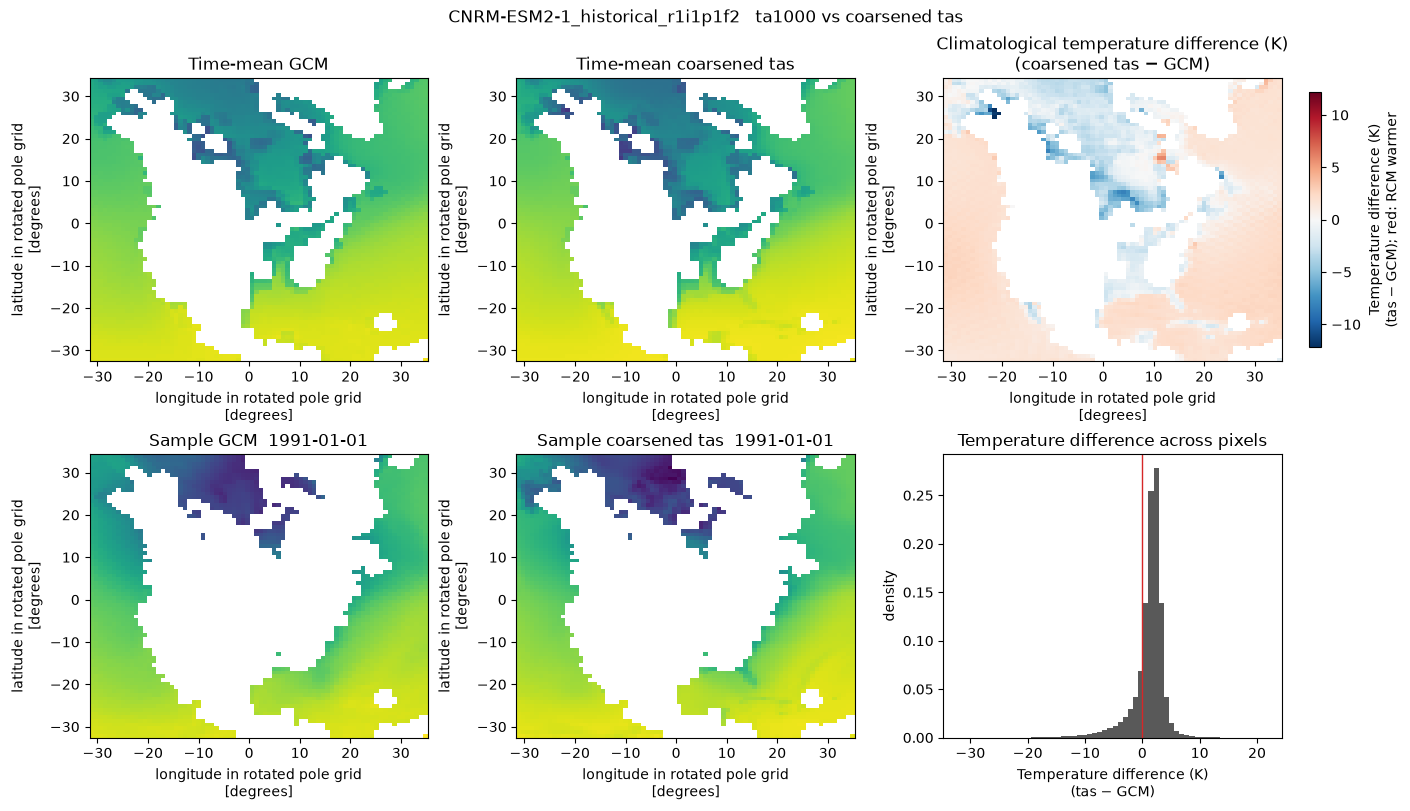

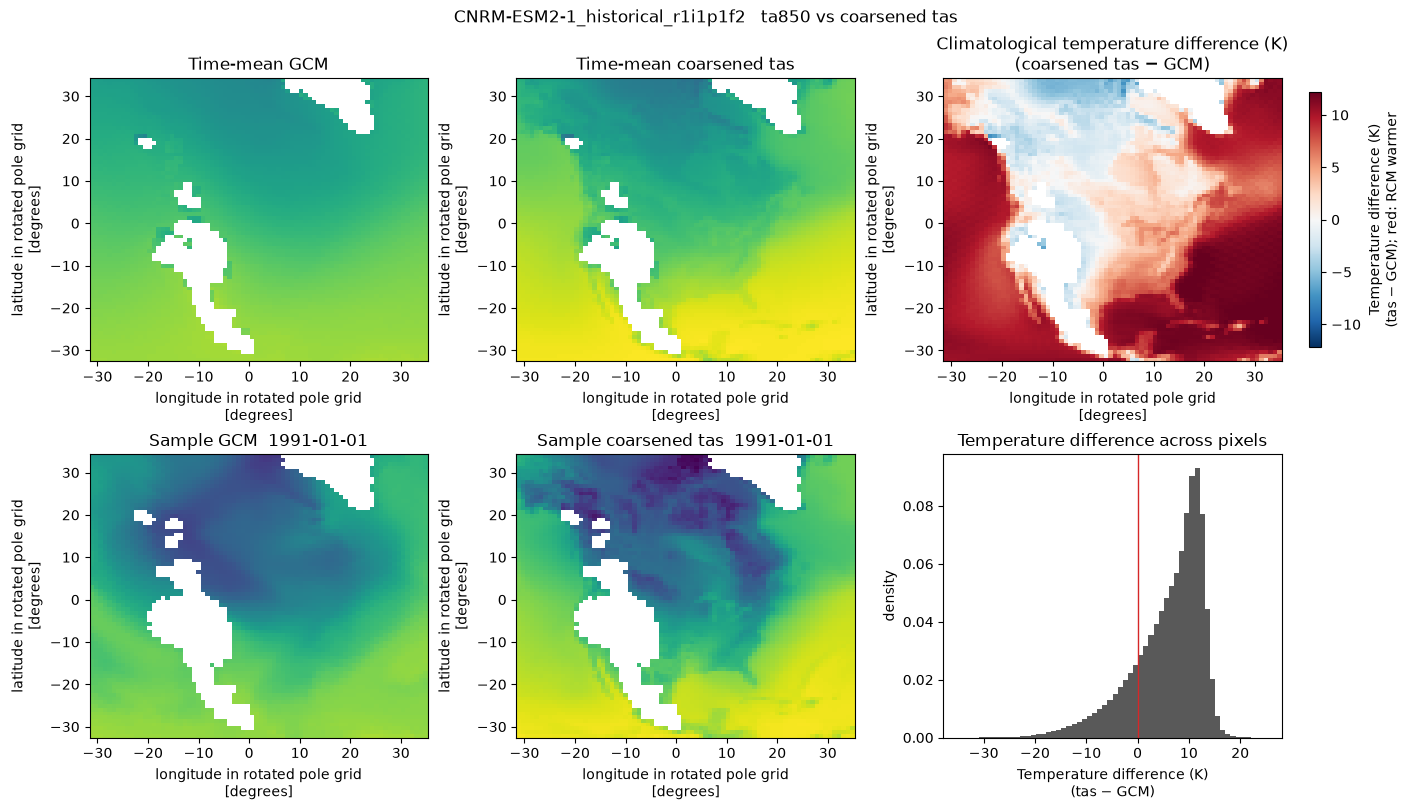

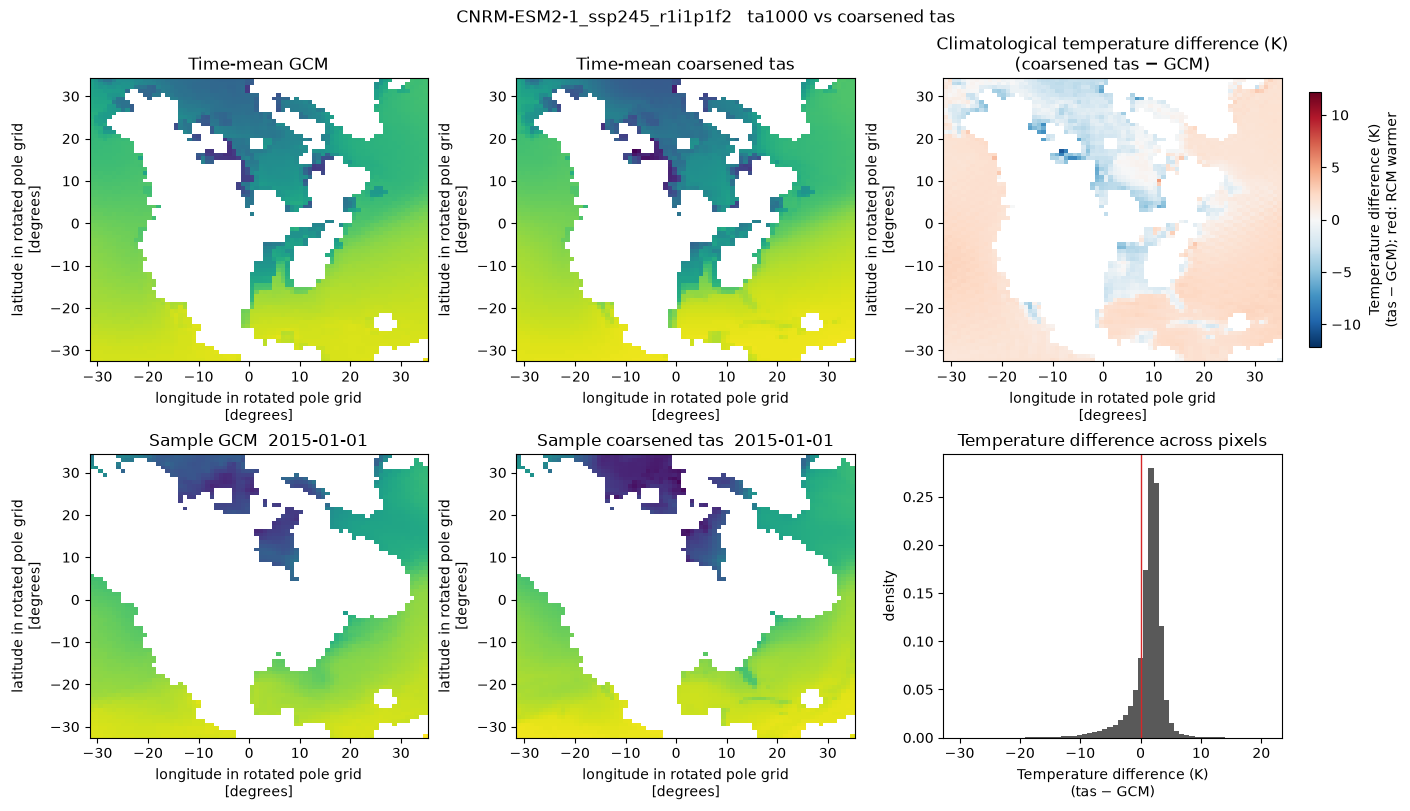

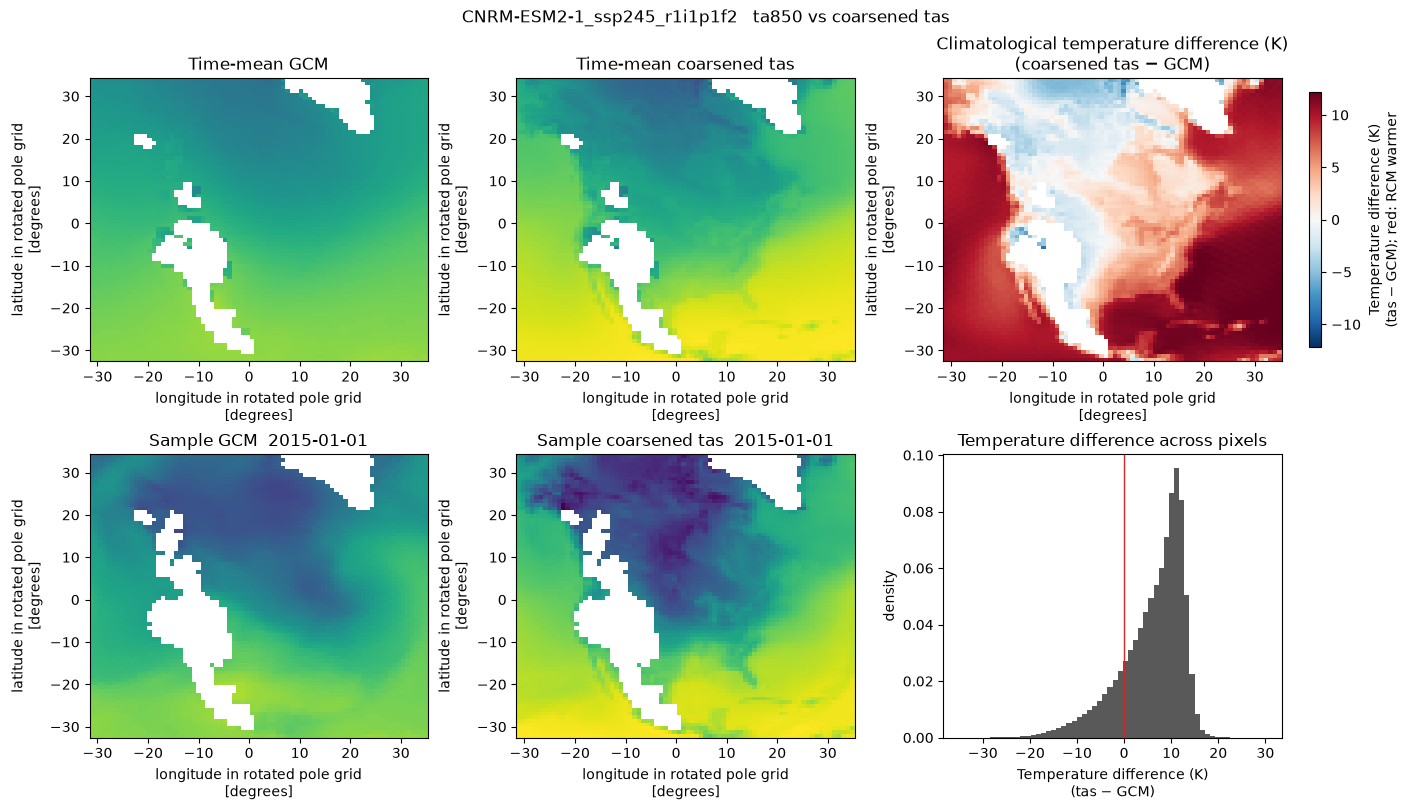

In [82]:

factor = int(config.coarsen_factor)
rows = []
pair_store = {}

for sim in data_gcm:
    tas_coarse = mean_pool_coarsen(data_crcm[sim]["tas"], factor)
    for gvar in dataset.gcm_variables:
        gcm = data_gcm[sim][gvar]
        rcm = map_rcm_to_gcm_grid(tas_coarse, gcm)
        stats = compare_gcm_rcm(gcm, rcm)
        pair_store[(sim, gvar)] = {**stats, "gcm": gcm, "rcm": rcm}
        rows.append({
            "sim": sim,
            "gcm": gvar,
            "rcm": "tas",
            "n_valid": stats["n_valid"],
            "pct_valid": stats["pct_valid_pixels"],
            "bias": stats["bias"],
            "mae": stats["mae"],
            "rmse": stats["rmse"],
            "pearson_r_clim": stats["pearson_r_clim"],
       
        })
        print(sim, gvar, "vs tas  n_valid=", stats["n_valid"])

pair_df = pd.DataFrame(rows)

# One symmetric bias scale for every figure (98th percentile of |tas − GCM| climatology).
bias_lim = 1.0
for stats in pair_store.values():
    diff_clim_vals = np.asarray(stats["rcm_climatology"] - stats["gcm_climatology"])
    p98 = float(np.nanpercentile(np.abs(diff_clim_vals), 98))
    if np.isfinite(p98):
        bias_lim = max(bias_lim, p98)

for (sim, gvar), stats in pair_store.items():
    gcm, rcm = stats["gcm"], stats["rcm"]
    valid = gcm.notnull() & rcm.notnull()
    diff = (rcm - gcm).where(valid)
    sample_step = max(1, int(gcm.sizes["time"]) // 400)
    g0, r0, d_sub, t0 = dask.compute(
        gcm.where(valid).isel(time=0),
        rcm.where(valid).isel(time=0),
        diff.isel(time=slice(None, None, sample_step)),
        gcm["time"].isel(time=0),
    )
    date_label = str(t0.values)[:10]
    gcm_climatology, rcm_climatology = stats["gcm_climatology"], stats["rcm_climatology"]
    diff_clim = (rcm_climatology - gcm_climatology)
    vmin = float(np.nanmin([gcm_climatology.min(), rcm_climatology.min(), g0.min(), r0.min()]))
    vmax = float(np.nanmax([gcm_climatology.max(), rcm_climatology.max(), g0.max(), r0.max()]))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
    gcm_climatology.plot(ax=axes[0, 0], vmin=vmin, vmax=vmax, add_colorbar=False)
    rcm_climatology.plot(ax=axes[0, 1], vmin=vmin, vmax=vmax, add_colorbar=False)
    im_c = diff_clim.plot(
        ax=axes[0, 2], vmin=-bias_lim, vmax=bias_lim, cmap="RdBu_r", add_colorbar=False,
    )
    axes[0, 0].set_title("Time-mean GCM")
    axes[0, 1].set_title("Time-mean coarsened tas")
    axes[0, 2].set_title("Climatological temperature difference (K)\n(coarsened tas − GCM)")

    g0.plot(ax=axes[1, 0], vmin=vmin, vmax=vmax, add_colorbar=False)
    r0.plot(ax=axes[1, 1], vmin=vmin, vmax=vmax, add_colorbar=False)

    cbar = fig.colorbar(im_c, ax=axes[0, 2], fraction=0.046, pad=0.08, shrink=0.9)
    cbar.set_label("Temperature difference (K)\n(tas − GCM); red: RCM warmer")

    diffs = np.asarray(d_sub.values).ravel()
    diffs = diffs[np.isfinite(diffs)]
    axes[1, 2].hist(diffs, bins=60, density=True, color="0.35")
    axes[1, 2].axvline(0.0, color="C3", linewidth=1)
    axes[1, 2].set_xlabel("Temperature difference (K)\n(tas − GCM)")
    axes[1, 2].set_ylabel("density")
    axes[1, 2].set_title("Temperature difference across pixels")
    axes[1, 0].set_title(f"Sample GCM  {date_label}")
    axes[1, 1].set_title(f"Sample coarsened tas  {date_label}")
    fig.suptitle(f"{sim}   {gvar} vs coarsened tas")
    plt.show()


In [79]:
pair_df

,sim,gcm,rcm,n_valid,pct_valid,bias,mae,rmse,pearson_r_clim
0,CNRM-ESM2-1_historical_r1i1p1f2,ta1000,tas,26393592,52.13,1.14,2.37,3.03,1.00
1,CNRM-ESM2-1_historical_r1i1p1f2,ta850,tas,45386741,89.64,5.87,8.02,9.06,0.96
2,CNRM-ESM2-1_ssp245_r1i1p1f2,ta1000,tas,6553294,51.76,1.21,2.35,2.98,1.00
3,CNRM-ESM2-1_ssp245_r1i1p1f2,ta850,tas,11345913,89.61,5.95,8.00,9.03,0.96
